# Clase 3 · Árboles multiperiodo y calibración de Hull-White

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prof-rodolfo-medina/modelizacion-derivados-carteras/blob/main/sesiones/semana-03/clase-03-arboles-multiperiodo-hull-white.ipynb)

**Semana 3 (16–20/11/2026) · Tema 4 · 60 min**

Objetivos:
1. Construir el árbol recombinante del subyacente y valorar por inducción hacia atrás.
2. Contrastar con la fórmula cerrada binomial.
3. Explorar la sensibilidad de la prima (Tabla 1 del tema).
4. Calibrar $u$ y $d$ a partir de datos con el algoritmo de Hull-White.

In [1]:
# Configuración: funciona en local (repositorio clonado) y en Google Colab
import sys, subprocess, pathlib
try:
    import mvdc
except ImportError:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "git+https://github.com/prof-rodolfo-medina/modelizacion-derivados-carteras.git"], check=True)
    else:
        for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
            if (base / "src" / "mvdc").exists():
                sys.path.insert(0, str(base / "src"))
                break
    import mvdc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})
print("mvdc", mvdc.__version__)

mvdc 2026.11


## 1. Árbol del subyacente (Figura 4 del tema): $S_0=100$, $u=1.1$, $d=0.9$, 3 periodos

In [2]:
from mvdc import binomial as b

S = b.stock_tree(100, 1.1, 0.9, 3)
b.print_tree(S)

   100.00   110.00   121.00   133.10
             90.00    99.00   108.90
                      81.00    89.10
                               72.90


## 2. Árbol de la call ($K=105$, $r=0.05$) por inducción hacia atrás (Figura 7)

In [3]:
V, q = b.option_tree(100, 105, 1.1, 0.9, 0.05, 3, kind="call")
print(f"q* = {q:.4f}")
b.print_tree(V)
print(f"\nPrima por inducción: {V[0,0]:.4f}   |   fórmula cerrada: {b.binomial_price(100, 105, 1.1, 0.9, 0.05, 3):.4f}")

q* = 0.7564
    11.87    15.85    21.12    28.10
              2.02     2.81     3.90
                       0.00     0.00
                                0.00

Prima por inducción: 11.8686   |   fórmula cerrada: 11.8686


## 3. Fórmula cerrada

$$V_0 = e^{-rn}\sum_{j=0}^{n}\binom{n}{j}(q^*)^{n-j}(1-q^*)^{j}\,(u^{n-j}d^{j}S_0-K)^+$$

Put con $K=100$ (el tema obtiene 1.601):

In [4]:
print(round(b.binomial_price(100, 100, 1.1, 0.9, 0.05, 3, kind="put"), 4))

1.6011


## 4. Análisis de sensibilidad (Tabla 1 del Tema 4)

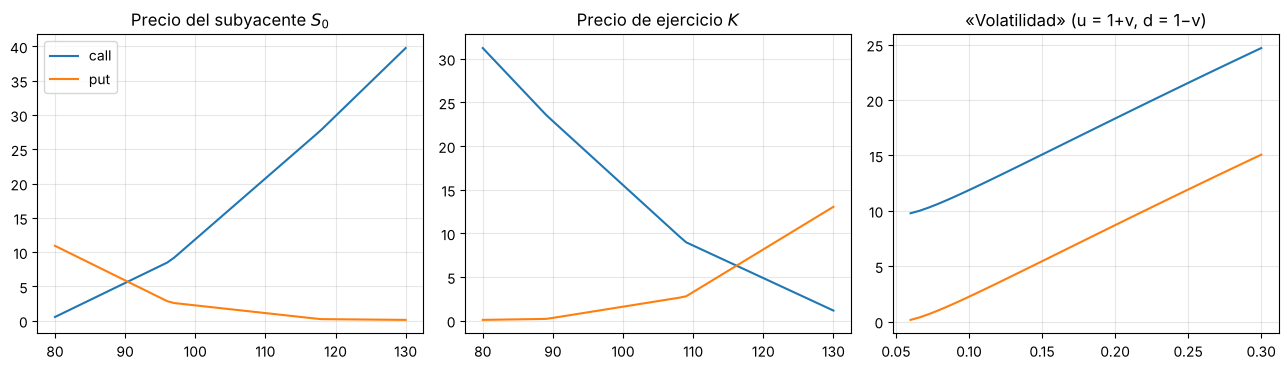

In [5]:
base = dict(S0=100, K=105, u=1.1, d=0.9, r=0.05, n=3)
def prima(kind="call", **cambios):
    p = {**base, **cambios}
    return b.binomial_price(p["S0"], p["K"], p["u"], p["d"], p["r"], p["n"], kind=kind)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
xs = np.linspace(80, 130, 51)
axs[0].plot(xs, [prima(S0=x) for x in xs], label="call"); axs[0].plot(xs, [prima("put", S0=x) for x in xs], label="put")
axs[0].set_title("Precio del subyacente $S_0$")
xs = np.linspace(80, 130, 51)
axs[1].plot(xs, [prima(K=x) for x in xs]); axs[1].plot(xs, [prima("put", K=x) for x in xs]); axs[1].set_title("Precio de ejercicio $K$")
vol = np.linspace(0.06, 0.3, 40)   # u = 1+v, d = 1-v; v > e^{0.05}-1 para que q* esté en (0,1)
axs[2].plot(vol, [prima(u=1+v, d=1-v) for v in vol]); axs[2].plot(vol, [prima("put", u=1+v, d=1-v) for v in vol])
axs[2].set_title("«Volatilidad» (u = 1+v, d = 1−v)")
axs[0].legend(); plt.tight_layout()

## 5. Calibración de Hull-White ($p=1/2$)

$$U_i=\frac{S_i}{S_{i-1}}-1,\qquad u = 1+\bar U + s_U,\qquad d = 1+\bar U - s_U.$$

Usamos las 28 cotizaciones del Tema 6 (incluidas en `datos/`).

In [6]:
serie = mvdc.datos.cargar("tema6_ibex_28dias.csv")["S"]
hw = b.hull_white_ud(serie)
print({k: round(v, 5) for k, v in hw.items()})

# Valoramos una call at-the-money a 5 días con los factores calibrados (r diario ≈ 3 % anual / 252)
S0 = serie.iloc[-1]
print("Prima call ATM a 5 días:", round(b.binomial_price(S0, S0, hw["u"], hw["d"], 0.03/252, 5), 4))

{'u': np.float64(1.01711), 'd': np.float64(0.98857), 'media': np.float64(0.00284), 'desv': np.float64(0.01427)}
Prima call ATM a 5 días: 0.3209


## 6. Ejercicio en clase

1. ¿Qué ocurre con $q^*$ si $e^{r\Delta t} > u$? Pruébalo con `b.risk_neutral_q`.
2. Avance del Tema 7: con $u=e^{\sigma\sqrt{\Delta t}}$ y $d=1/u$, grafica la prima binomial
   para $n = 1,\dots,200$. ¿Hacia qué valor converge? (lo veremos en la Clase 5).

In [7]:
# Tu código aquí

> **Recordatorio:** la Actividad 1 se entrega el **lunes 23/11/2026 a las 23:59**.